
# FULL PUBLICATION RUN — Q1-Ready Low-Compute Healthcare AI: Genetic Disorder Prediction

## Proposed title
**An Uncertainty-Aware Explainable Hierarchical Ensemble Learning Framework for Reliable Genetic Disorder and Subclass Prediction**

### Design goals
- Public tabular healthcare/genetics dataset (~22k rows, 45 columns)
- Configured directly for the **FULL publication run** in Google Colab; CPU is sufficient and T4 is optional
- Leakage-free hierarchical learning:
  1. Stage 1 predicts **Genetic Disorder**
  2. Stage 2 predicts **Disorder Subclass** using out-of-fold Stage-1 probabilities as context
- Advanced ensemble: **ExtraTrees + XGBoost + LightGBM**
- Probability calibration
- Split-conformal prediction sets for uncertainty
- SHAP explainability (with permutation-importance fallback)
- Robustness under missingness/noise
- Subgroup/fairness analysis
- Bootstrap confidence intervals
- Ablation study and paired-bootstrap significance test
- Automatic export of all tables, figures, predictions, and configuration

> **Important scientific note:** This notebook is designed to generate reproducible experimental evidence. It does **not** hard-code or fabricate target accuracy. Report only the metrics produced by your actual run.


In [1]:

#@title 1. Install dependencies
!pip -q install -U kagglehub lightgbm xgboost shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 47.1 MB/s eta 0:00:00


In [2]:

#@title 2. Imports, reproducibility and run mode
import os, re, json, math, time, random, warnings, zipfile, platform
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score,
    log_loss, confusion_matrix, classification_report, roc_auc_score
)
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED = 42
np.random.seed(SEED); random.seed(SEED)

# QUICK_RUN=True is intentionally the default for a fast verification run.
# Set QUICK_RUN=False for the complete publication run.
QUICK_RUN = False  # FULL publication run
N_SPLITS = 3 if QUICK_RUN else 5
BOOTSTRAPS = 300 if QUICK_RUN else 1500

OUT = Path("/content/genetic_q1_results")
OUT.mkdir(parents=True, exist_ok=True)

print("Python:", platform.python_version())
print("FULL_RUN:", not QUICK_RUN, "| CV folds:", N_SPLITS, "| Bootstrap replicates:", BOOTSTRAPS)
print("Results folder:", OUT)


Python: 3.13.15
FULL_RUN: True | CV folds: 5 | Bootstrap replicates: 1500
Results folder: /content/genetic_q1_results



## Dataset
Primary source: Kaggle dataset **“Predict the genetic disorders dataset-of genomes”** (`aibuzz/predict-the-genetic-disorders-datasetof-genomes`).

The source contains the same task structure needed here: patient clinical/hereditary variables with two labels:
- **Genetic Disorder** (broad category)
- **Disorder Subclass** (specific category)

The next cell downloads it with `kagglehub`, locates the training CSV automatically, and performs defensive validation so filename differences do not break the notebook.


In [3]:

#@title 3. Download and locate the dataset automatically
import kagglehub

DATASET_HANDLE = "aibuzz/predict-the-genetic-disorders-datasetof-genomes"
data_dir = Path(kagglehub.dataset_download(DATASET_HANDLE))
print("Dataset directory:", data_dir)

csvs = list(data_dir.rglob("*.csv"))
assert csvs, f"No CSV files found under {data_dir}"

print("CSV files found:")
for p in csvs:
    print(" -", p.name, f"({p.stat().st_size/1e6:.2f} MB)")

TARGET_STAGE1 = "Genetic Disorder"
TARGET_STAGE2 = "Disorder Subclass"

train_candidates = []
for p in csvs:
    try:
        head = pd.read_csv(p, nrows=5)
        cols = set(head.columns)
        if TARGET_STAGE1 in cols and TARGET_STAGE2 in cols:
            train_candidates.append(p)
    except Exception:
        pass

assert train_candidates, (
    "Could not find a CSV containing both target columns. "
    "Check that the Kaggle dataset version still contains the training data."
)

TRAIN_CSV = sorted(train_candidates, key=lambda p: p.stat().st_size, reverse=True)[0]
print("Using:", TRAIN_CSV)

df_raw = pd.read_csv(TRAIN_CSV)
print("Raw shape:", df_raw.shape)
display(df_raw.head())


100%|██████████| 1.73M/1.73M [00:01<00:00, 1.41MB/s]

Extracting files...


Dataset directory: /root/.cache/kagglehub/datasets/aibuzz/predict-the-genetic-disorders-datasetof-genomes/versions/1
CSV files found:
 - test_genetic_disorders.csv (2.46 MB)
 - train_genetic_disorders.csv (6.56 MB)
Using: /root/.cache/kagglehub/datasets/aibuzz/predict-the-genetic-disorders-datasetof-genomes/versions/1/train_genetic_disorders.csv
Raw shape: (22083, 45)


,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,PID0x6418,2.0,Yes,No,Yes,No,4.760603,Richard,NaN,Larre,...,NaN,9.857562,NaN,1.0,1.0,1.0,1.0,1.0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,PID0x25d5,4.0,Yes,Yes,No,No,4.910669,Mike,NaN,Brycen,...,Multiple,5.522560,normal,1.0,NaN,1.0,1.0,0.0,NaN,Cystic fibrosis
2,PID0x4a82,6.0,Yes,No,No,No,4.893297,Kimberly,NaN,Nashon,...,Singular,NaN,normal,0.0,1.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes
3,PID0x4ac8,12.0,Yes,No,Yes,No,4.705280,Jeffery,Hoelscher,Aayaan,...,Singular,7.919321,inconclusive,0.0,0.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
4,PID0x1bf7,11.0,Yes,No,NaN,Yes,4.720703,Johanna,Stutzman,Suave,...,Multiple,4.098210,NaN,0.0,0.0,0.0,0.0,NaN,Multifactorial genetic inheritance disorders,Cancer


In [4]:

#@title 4. Data audit and leakage-safe cleaning
df = df_raw.copy()

# Normalize whitespace in column names but preserve readable labels.
df.columns = [re.sub(r"\s+", " ", str(c)).strip() for c in df.columns]

assert TARGET_STAGE1 in df.columns and TARGET_STAGE2 in df.columns

# Remove rows without either target; these cannot support the hierarchical supervised task.
before = len(df)
df = df.dropna(subset=[TARGET_STAGE1, TARGET_STAGE2]).reset_index(drop=True)
print(f"Dropped {before-len(df)} rows missing one/both targets; retained {len(df)}.")

# Remove direct identifiers / names to avoid memorization and privacy leakage.
identifier_patterns = [
    r"patient\s*id", r"first\s*name", r"family\s*name", r"^name$", r"^id$"
]
drop_cols = []
for c in df.columns:
    lc = c.lower()
    if any(re.search(pat, lc) for pat in identifier_patterns):
        drop_cols.append(c)

# Also remove columns that are effectively unique identifiers.
for c in df.columns:
    if c not in [TARGET_STAGE1, TARGET_STAGE2] and c not in drop_cols:
        nun = df[c].nunique(dropna=True)
        if nun > 0.95 * len(df) and df[c].dtype == "object":
            drop_cols.append(c)

drop_cols = sorted(set(drop_cols))
print("Identifier/high-cardinality columns removed:", drop_cols)

X = df.drop(columns=[TARGET_STAGE1, TARGET_STAGE2] + drop_cols, errors="ignore").copy()
y1_text = df[TARGET_STAGE1].astype(str).str.strip()
y2_text = df[TARGET_STAGE2].astype(str).str.strip()

print("Features:", X.shape[1])
print("\nStage-1 classes:")
display(y1_text.value_counts().to_frame("count"))
print("\nStage-2 classes:")
display(y2_text.value_counts().to_frame("count"))

# Defensive cleanup for object columns
for c in X.select_dtypes(include=["object", "category"]).columns:
    X[c] = X[c].replace({"": np.nan, "nan": np.nan, "None": np.nan})


Dropped 4923 rows missing one/both targets; retained 17160.
Identifier/high-cardinality columns removed: ['Family Name', 'Patient First Name', 'Patient Id']
Features: 40

Stage-1 classes:


,count
Genetic Disorder,
Mitochondrial genetic inheritance disorders,8766
Single-gene inheritance diseases,6591
Multifactorial genetic inheritance disorders,1803



Stage-2 classes:


,count
Disorder Subclass,
Leigh syndrome,4434
Mitochondrial myopathy,3780
Cystic fibrosis,2985
Tay-Sachs,2434
Diabetes,1586
Hemochromatosis,1172
Leber's hereditary optic neuropathy,552
Alzheimer's,130
Cancer,87


In [5]:

#@title 5. Biologically motivated, low-cost feature engineering
def add_biological_features(Xin: pd.DataFrame) -> pd.DataFrame:
    Xo = Xin.copy()

    # Missingness is itself clinically informative in many tabular health records.
    Xo["record_missing_count"] = Xo.isna().sum(axis=1)
    Xo["record_missing_fraction"] = Xo.isna().mean(axis=1)

    # Robust yes/no mapping helper without assuming exact capitalization.
    def yn(col):
        if col not in Xo.columns:
            return None
        s = Xo[col].astype(str).str.lower().str.strip()
        return s.map({"yes":1, "no":0, "true":1, "false":0, "1":1, "0":0})

    mother = yn("Genes in mother's side")
    father = yn("Inherited from father")
    maternal = yn("Maternal gene")
    paternal = yn("Paternal gene")

    inherited_parts = [s for s in [mother, father, maternal, paternal] if s is not None]
    if inherited_parts:
        Xo["inheritance_evidence_count"] = pd.concat(inherited_parts, axis=1).sum(axis=1, min_count=1)
        Xo["inheritance_evidence_fraction"] = pd.concat(inherited_parts, axis=1).mean(axis=1)

    # Symptom burden: columns in this dataset commonly contain "Symptom".
    symptom_cols = [c for c in Xo.columns if "symptom" in c.lower()]
    if symptom_cols:
        tmp = []
        for c in symptom_cols:
            s = pd.to_numeric(Xo[c], errors="coerce")
            if s.notna().mean() < 0.5:
                s = Xo[c].astype(str).str.lower().map({"yes":1,"no":0,"true":1,"false":0})
            tmp.append(s)
        sm = pd.concat(tmp, axis=1)
        Xo["symptom_burden"] = sm.sum(axis=1, min_count=1)
        Xo["symptom_observed_count"] = sm.notna().sum(axis=1)

    # Parent-age context when available.
    age_cols = [c for c in Xo.columns if "age" in c.lower()]
    mother_age = next((c for c in age_cols if "mother" in c.lower() or "maternal" in c.lower()), None)
    father_age = next((c for c in age_cols if "father" in c.lower() or "paternal" in c.lower()), None)
    if mother_age and father_age:
        ma = pd.to_numeric(Xo[mother_age], errors="coerce")
        fa = pd.to_numeric(Xo[father_age], errors="coerce")
        Xo["parent_age_mean"] = (ma + fa) / 2
        Xo["parent_age_gap_abs"] = (fa - ma).abs()

    return Xo

X_fe = add_biological_features(X)
print("Raw feature count:", X.shape[1])
print("Engineered feature count:", X_fe.shape[1])


Raw feature count: 40
Engineered feature count: 48


In [6]:

#@title 6. Encode targets and create untouched train/calibration/test splits
le1 = LabelEncoder()
le2 = LabelEncoder()
y1 = le1.fit_transform(y1_text)
y2 = le2.fit_transform(y2_text)

# 70% fit / 15% calibration / 15% final test.
# Stratify by subclass where possible; subclass is the harder endpoint.
idx = np.arange(len(X_fe))
idx_fitcal, idx_test = train_test_split(
    idx, test_size=0.15, random_state=SEED, stratify=y2
)
idx_fit, idx_cal = train_test_split(
    idx_fitcal, test_size=0.1764705882, random_state=SEED, stratify=y2[idx_fitcal]
)

X_fit = X_fe.iloc[idx_fit].reset_index(drop=True)
X_cal = X_fe.iloc[idx_cal].reset_index(drop=True)
X_test = X_fe.iloc[idx_test].reset_index(drop=True)

y1_fit, y1_cal, y1_test = y1[idx_fit], y1[idx_cal], y1[idx_test]
y2_fit, y2_cal, y2_test = y2[idx_fit], y2[idx_cal], y2[idx_test]

print("Fit:", X_fit.shape, "Calibration:", X_cal.shape, "Test:", X_test.shape)
print("Stage-1 labels:", list(le1.classes_))
print("Stage-2 labels:", list(le2.classes_))


Fit: (12012, 48) Calibration: (2574, 48) Test: (2574, 48)
Stage-1 labels: ['Mitochondrial genetic inheritance disorders', 'Multifactorial genetic inheritance disorders', 'Single-gene inheritance diseases']
Stage-2 labels: ["Alzheimer's", 'Cancer', 'Cystic fibrosis', 'Diabetes', 'Hemochromatosis', "Leber's hereditary optic neuropathy", 'Leigh syndrome', 'Mitochondrial myopathy', 'Tay-Sachs']


In [7]:

#@title 7. Preprocessing and compact model factory
def make_preprocessor(Xdf):
    num_cols = Xdf.select_dtypes(include=np.number).columns.tolist()
    cat_cols = [c for c in Xdf.columns if c not in num_cols]

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=2, sparse_output=True))
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ], remainder="drop"), num_cols, cat_cols

preprocessor, numeric_cols, categorical_cols = make_preprocessor(X_fit)
preprocessor.fit(X_fit)

Z_fit = preprocessor.transform(X_fit)
Z_cal = preprocessor.transform(X_cal)
Z_test = preprocessor.transform(X_test)

print("Encoded shapes:", Z_fit.shape, Z_cal.shape, Z_test.shape)
print("Numeric:", len(numeric_cols), "| Categorical:", len(categorical_cols))

def model_factory(n_classes):
    # Conservative settings chosen for Colab CPU efficiency.
    et = ExtraTreesClassifier(
        n_estimators=180 if QUICK_RUN else 500,
        max_features="sqrt", min_samples_leaf=2,
        class_weight="balanced", random_state=SEED, n_jobs=-1
    )
    xgb = XGBClassifier(
        n_estimators=180 if QUICK_RUN else 450,
        max_depth=5, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        reg_lambda=1.5, reg_alpha=0.05,
        objective="multi:softprob", num_class=n_classes,
        eval_metric="mlogloss", tree_method="hist",
        random_state=SEED, n_jobs=-1
    )
    lgb = LGBMClassifier(
        n_estimators=180 if QUICK_RUN else 450,
        learning_rate=0.04, num_leaves=31,
        subsample=0.85, colsample_bytree=0.85,
        reg_lambda=1.0, class_weight="balanced",
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    return {"ExtraTrees": et, "XGBoost": xgb, "LightGBM": lgb}

def normalize_prob(p):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, 1e-12, None)
    return p / p.sum(axis=1, keepdims=True)

def average_probs(prob_dict, weights=None):
    names = list(prob_dict)
    if weights is None:
        weights = np.ones(len(names))/len(names)
    weights = np.asarray(weights, dtype=float); weights /= weights.sum()
    p = sum(w * normalize_prob(prob_dict[n]) for w, n in zip(weights, names))
    return normalize_prob(p)


Encoded shapes: (12012, 1803) (2574, 1803) (2574, 1803)
Numeric: 24 | Categorical: 24


In [8]:

#@title 8. Utility metrics: discrimination + calibration
def multiclass_brier(y_true, prob, n_classes):
    Y = np.eye(n_classes)[y_true]
    return float(np.mean(np.sum((prob - Y)**2, axis=1)))

def ece_score(y_true, prob, bins=10):
    conf = prob.max(axis=1)
    pred = prob.argmax(axis=1)
    correct = (pred == y_true).astype(float)
    edges = np.linspace(0, 1, bins+1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf > lo) & (conf <= hi)
        if mask.any():
            ece += mask.mean() * abs(correct[mask].mean() - conf[mask].mean())
    return float(ece)

def metric_row(name, y_true, prob):
    pred = prob.argmax(axis=1)
    n_classes = prob.shape[1]
    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, pred),
        "BalancedAccuracy": balanced_accuracy_score(y_true, pred),
        "MacroPrecision": precision_score(y_true, pred, average="macro", zero_division=0),
        "MacroRecall": recall_score(y_true, pred, average="macro", zero_division=0),
        "MacroF1": f1_score(y_true, pred, average="macro", zero_division=0),
        "WeightedF1": f1_score(y_true, pred, average="weighted", zero_division=0),
        "LogLoss": log_loss(y_true, prob, labels=np.arange(n_classes)),
        "Brier": multiclass_brier(y_true, prob, n_classes),
        "ECE": ece_score(y_true, prob),
    }
    try:
        row["MacroAUROC_OVR"] = roc_auc_score(
            y_true, prob, multi_class="ovr", average="macro",
            labels=np.arange(n_classes)
        )
    except Exception:
        row["MacroAUROC_OVR"] = np.nan
    return row


In [9]:

#@title 9. Stage 1: leakage-free OOF broad-disorder probabilities
stage1_models = model_factory(len(le1.classes_))
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof1_each = {name: np.zeros((len(y1_fit), len(le1.classes_))) for name in stage1_models}

for fold, (tr, va) in enumerate(skf.split(np.zeros(len(y1_fit)), y1_fit), 1):
    print(f"Stage 1 fold {fold}/{N_SPLITS}")
    for name, base_model in stage1_models.items():
        m = clone(base_model)
        m.fit(Z_fit[tr], y1_fit[tr])
        oof1_each[name][va] = m.predict_proba(Z_fit[va])

# Weight models using OOF macro-F1 (nonnegative and normalized).
s1_scores = {}
for name, p in oof1_each.items():
    s1_scores[name] = f1_score(y1_fit, p.argmax(1), average="macro")
weights1 = np.array([max(s1_scores[n], 1e-6) for n in stage1_models])
weights1 /= weights1.sum()

oof1 = average_probs(oof1_each, weights1)
print("Stage-1 OOF macro-F1 by model:", s1_scores)
print("Stage-1 ensemble weights:", dict(zip(stage1_models, weights1.round(4))))

# Fit final stage-1 models on all fitting data, then predict calibration/test.
stage1_fitted = {}
p1_cal_each, p1_test_each = {}, {}
for name, base_model in stage1_models.items():
    m = clone(base_model)
    m.fit(Z_fit, y1_fit)
    stage1_fitted[name] = m
    p1_cal_each[name] = m.predict_proba(Z_cal)
    p1_test_each[name] = m.predict_proba(Z_test)

p1_cal = average_probs(p1_cal_each, weights1)
p1_test = average_probs(p1_test_each, weights1)

stage1_results = pd.DataFrame([
    metric_row("Stage1_HierarchicalEnsemble", y1_test, p1_test)
])
display(stage1_results.round(4))
stage1_results.to_csv(OUT/"stage1_test_metrics.csv", index=False)


Stage 1 fold 1/5
Stage 1 fold 2/5
Stage 1 fold 3/5
Stage 1 fold 4/5
Stage 1 fold 5/5
Stage-1 OOF macro-F1 by model: {'ExtraTrees': 0.5199323005534712, 'XGBoost': 0.531005668491353, 'LightGBM': 0.5458877870165318}
Stage-1 ensemble weights: {'ExtraTrees': np.float64(0.3256), 'XGBoost': np.float64(0.3325), 'LightGBM': np.float64(0.3419)}


,Model,Accuracy,BalancedAccuracy,MacroPrecision,MacroRecall,MacroF1,WeightedF1,LogLoss,Brier,ECE,MacroAUROC_OVR
0,Stage1_HierarchicalEnsemble,0.615,0.5824,0.5632,0.5824,0.5656,0.6075,0.8137,0.5008,0.0586,0.7666


In [10]:

#@title 10. Stage 2: subclass prediction with hierarchical probability context
from scipy import sparse

# Append broad-disorder probabilities as contextual features.
Z2_fit = sparse.hstack([Z_fit, sparse.csr_matrix(oof1)], format="csr")
Z2_cal = sparse.hstack([Z_cal, sparse.csr_matrix(p1_cal)], format="csr")
Z2_test = sparse.hstack([Z_test, sparse.csr_matrix(p1_test)], format="csr")

stage2_models = model_factory(len(le2.classes_))
stage2_fitted = {}
p2_cal_each, p2_test_each = {}, {}

# Use a validation slice within fit only to derive ensemble weights without touching calibration/test.
tr2, va2 = train_test_split(
    np.arange(len(y2_fit)), test_size=0.18, random_state=SEED, stratify=y2_fit
)
s2_scores = {}

for name, base_model in stage2_models.items():
    probe = clone(base_model)
    probe.fit(Z2_fit[tr2], y2_fit[tr2])
    pv = probe.predict_proba(Z2_fit[va2])
    s2_scores[name] = f1_score(y2_fit[va2], pv.argmax(1), average="macro")

weights2 = np.array([max(s2_scores[n], 1e-6) for n in stage2_models])
weights2 /= weights2.sum()

print("Stage-2 validation macro-F1:", s2_scores)
print("Stage-2 ensemble weights:", dict(zip(stage2_models, weights2.round(4))))

for name, base_model in stage2_models.items():
    m = clone(base_model)
    m.fit(Z2_fit, y2_fit)
    stage2_fitted[name] = m
    p2_cal_each[name] = m.predict_proba(Z2_cal)
    p2_test_each[name] = m.predict_proba(Z2_test)

p2_cal_raw = average_probs(p2_cal_each, weights2)
p2_test_raw = average_probs(p2_test_each, weights2)

raw_results = pd.DataFrame([
    metric_row("Proposed_Hierarchical_Ensemble_Raw", y2_test, p2_test_raw)
])
display(raw_results.round(4))


Stage-2 validation macro-F1: {'ExtraTrees': 0.28524653129411487, 'XGBoost': 0.32940962194711115, 'LightGBM': 0.3289053589102819}
Stage-2 ensemble weights: {'ExtraTrees': np.float64(0.3023), 'XGBoost': np.float64(0.3491), 'LightGBM': np.float64(0.3486)}


,Model,Accuracy,BalancedAccuracy,MacroPrecision,MacroRecall,MacroF1,WeightedF1,LogLoss,Brier,ECE,MacroAUROC_OVR
0,Proposed_Hierarchical_Ensemble_Raw,0.3854,0.2653,0.2814,0.2653,0.2685,0.3788,1.3721,0.7026,0.025,0.8617


In [11]:

#@title 11. Temperature scaling for better probability calibration
from scipy.optimize import minimize_scalar

def temperature_scale(prob, T):
    logits = np.log(np.clip(prob, 1e-12, 1.0))
    scaled = logits / max(float(T), 1e-6)
    scaled -= scaled.max(axis=1, keepdims=True)
    e = np.exp(scaled)
    return e / e.sum(axis=1, keepdims=True)

def objective_T(T):
    return log_loss(y2_cal, temperature_scale(p2_cal_raw, T),
                    labels=np.arange(len(le2.classes_)))

opt = minimize_scalar(objective_T, bounds=(0.25, 5.0), method="bounded")
T_star = float(opt.x)

p2_cal = temperature_scale(p2_cal_raw, T_star)
p2_test = temperature_scale(p2_test_raw, T_star)

calibration_results = pd.DataFrame([
    metric_row("Hierarchical_Raw", y2_test, p2_test_raw),
    metric_row("Hierarchical_TemperatureScaled", y2_test, p2_test)
])
print("Optimal temperature:", round(T_star, 4))
display(calibration_results.round(4))
calibration_results.to_csv(OUT/"calibration_comparison.csv", index=False)


Optimal temperature: 0.7621


,Model,Accuracy,BalancedAccuracy,MacroPrecision,MacroRecall,MacroF1,WeightedF1,LogLoss,Brier,ECE,MacroAUROC_OVR
0,Hierarchical_Raw,0.3854,0.2653,0.2814,0.2653,0.2685,0.3788,1.3721,0.7026,0.0250,0.8617
1,Hierarchical_TemperatureScaled,0.3854,0.2653,0.2814,0.2653,0.2685,0.3788,1.3546,0.7117,0.0813,0.8612


In [12]:

#@title 12. Split-conformal prediction sets (class-conditional probability uncertainty)
def conformal_quantile(scores, alpha):
    n = len(scores)
    q_level = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
    return float(np.quantile(scores, q_level, method="higher"))

def conformal_sets(cal_prob, cal_y, test_prob, alpha=0.10):
    # Nonconformity = 1 - probability assigned to the true class.
    scores = 1.0 - cal_prob[np.arange(len(cal_y)), cal_y]
    q = conformal_quantile(scores, alpha)
    threshold = 1.0 - q
    sets = test_prob >= threshold

    # Ensure no empty sets (finite-sample numerical safeguard).
    empty = np.where(sets.sum(axis=1) == 0)[0]
    if len(empty):
        sets[empty, test_prob[empty].argmax(axis=1)] = True
    return sets, q, threshold

coverage_rows = []
conformal_outputs = {}

for alpha in [0.05, 0.10, 0.20]:
    sets, q, thr = conformal_sets(p2_cal, y2_cal, p2_test, alpha)
    covered = sets[np.arange(len(y2_test)), y2_test]
    sizes = sets.sum(axis=1)
    row = {
        "NominalCoverage": 1-alpha,
        "EmpiricalCoverage": covered.mean(),
        "MeanSetSize": sizes.mean(),
        "MedianSetSize": np.median(sizes),
        "SingletonRate": (sizes == 1).mean(),
        "ConformalQuantile": q,
        "ProbabilityThreshold": thr
    }
    coverage_rows.append(row)
    conformal_outputs[alpha] = sets

conformal_table = pd.DataFrame(coverage_rows)
display(conformal_table.round(4))
conformal_table.to_csv(OUT/"conformal_prediction_sets.csv", index=False)


,NominalCoverage,EmpiricalCoverage,MeanSetSize,MedianSetSize,SingletonRate,ConformalQuantile,ProbabilityThreshold
0,0.95,0.9433,3.3357,3.0,0.0008,0.9410,0.0590
1,0.90,0.8784,2.8244,3.0,0.0051,0.8941,0.1059
2,0.80,0.7836,2.2813,2.0,0.0556,0.8257,0.1743


In [13]:

#@title 13. Baselines + ablation study
# A lightweight baseline: ExtraTrees on engineered features without Stage-1 context.
flat_et = ExtraTreesClassifier(
    n_estimators=180 if QUICK_RUN else 500,
    max_features="sqrt", min_samples_leaf=2,
    class_weight="balanced", random_state=SEED, n_jobs=-1
)
flat_et.fit(Z_fit, y2_fit)
p_flat = flat_et.predict_proba(Z_test)

# Raw-feature ablation: no added biological features.
pre_raw, _, _ = make_preprocessor(X.iloc[idx_fit].reset_index(drop=True))
Zraw_fit = pre_raw.fit_transform(X.iloc[idx_fit].reset_index(drop=True))
Zraw_test = pre_raw.transform(X.iloc[idx_test].reset_index(drop=True))
raw_et = ExtraTreesClassifier(
    n_estimators=180 if QUICK_RUN else 500,
    max_features="sqrt", min_samples_leaf=2,
    class_weight="balanced", random_state=SEED, n_jobs=-1
)
raw_et.fit(Zraw_fit, y2_fit)
p_raw_et = raw_et.predict_proba(Zraw_test)

ablation = pd.DataFrame([
    metric_row("A0_RawFeatures_ExtraTrees", y2_test, p_raw_et),
    metric_row("A1_BioFeatures_ExtraTrees", y2_test, p_flat),
    metric_row("A2_Hierarchical_Ensemble", y2_test, p2_test_raw),
    metric_row("A3_Hierarchical_Ensemble_Calibrated", y2_test, p2_test),
])
display(ablation.round(4))
ablation.to_csv(OUT/"ablation_study.csv", index=False)


,Model,Accuracy,BalancedAccuracy,MacroPrecision,MacroRecall,MacroF1,WeightedF1,LogLoss,Brier,ECE,MacroAUROC_OVR
0,A0_RawFeatures_ExtraTrees,0.3454,0.2656,0.2818,0.2656,0.2684,0.3419,1.8020,0.8034,0.1616,0.8243
1,A1_BioFeatures_ExtraTrees,0.3594,0.2718,0.2887,0.2718,0.2750,0.3558,1.7182,0.7835,0.1572,0.8422
2,A2_Hierarchical_Ensemble,0.3854,0.2653,0.2814,0.2653,0.2685,0.3788,1.3721,0.7026,0.0250,0.8617
3,A3_Hierarchical_Ensemble_Calibrated,0.3854,0.2653,0.2814,0.2653,0.2685,0.3788,1.3546,0.7117,0.0813,0.8612


In [14]:

#@title 14. Bootstrap confidence intervals + paired significance test
def bootstrap_metric_ci(y, prob, metric="macro_f1", B=1000, seed=42):
    rng = np.random.default_rng(seed)
    vals = []
    n = len(y)
    pred = prob.argmax(1)
    for _ in range(B):
        ix = rng.integers(0, n, n)
        if metric == "macro_f1":
            vals.append(f1_score(y[ix], pred[ix], average="macro", zero_division=0))
        elif metric == "accuracy":
            vals.append(accuracy_score(y[ix], pred[ix]))
    vals = np.array(vals)
    return float(vals.mean()), float(np.quantile(vals, .025)), float(np.quantile(vals, .975))

ci_rows = []
for name, p in {
    "Raw ExtraTrees": p_raw_et,
    "BioFeature ExtraTrees": p_flat,
    "Proposed calibrated hierarchy": p2_test
}.items():
    mean, lo, hi = bootstrap_metric_ci(y2_test, p, "macro_f1", BOOTSTRAPS, SEED)
    ci_rows.append({"Model":name, "Metric":"MacroF1", "BootstrapMean":mean, "CI95_Low":lo, "CI95_High":hi})
    mean, lo, hi = bootstrap_metric_ci(y2_test, p, "accuracy", BOOTSTRAPS, SEED+1)
    ci_rows.append({"Model":name, "Metric":"Accuracy", "BootstrapMean":mean, "CI95_Low":lo, "CI95_High":hi})

ci_table = pd.DataFrame(ci_rows)
display(ci_table.round(4))
ci_table.to_csv(OUT/"bootstrap_confidence_intervals.csv", index=False)

# Paired bootstrap: proposed vs strongest simple flat baseline, macro-F1.
rng = np.random.default_rng(SEED)
diffs = []
pred_prop = p2_test.argmax(1)
pred_base = p_flat.argmax(1)
for _ in range(BOOTSTRAPS):
    ix = rng.integers(0, len(y2_test), len(y2_test))
    d = (f1_score(y2_test[ix], pred_prop[ix], average="macro", zero_division=0)
         - f1_score(y2_test[ix], pred_base[ix], average="macro", zero_division=0))
    diffs.append(d)
diffs = np.asarray(diffs)
p_two_sided = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
sig = pd.DataFrame([{
    "Comparison":"Proposed calibrated hierarchy - BioFeature ExtraTrees",
    "MeanMacroF1Difference":diffs.mean(),
    "CI95_Low":np.quantile(diffs,.025),
    "CI95_High":np.quantile(diffs,.975),
    "PairedBootstrapPValue":min(float(p_two_sided),1.0)
}])
display(sig.round(5))
sig.to_csv(OUT/"paired_bootstrap_significance.csv", index=False)


,Model,Metric,BootstrapMean,CI95_Low,CI95_High
0,Raw ExtraTrees,MacroF1,0.2677,0.2442,0.2944
1,Raw ExtraTrees,Accuracy,0.3457,0.3279,0.3636
2,BioFeature ExtraTrees,MacroF1,0.2743,0.2505,0.3004
3,BioFeature ExtraTrees,Accuracy,0.3592,0.3413,0.3772
4,Proposed calibrated hierarchy,MacroF1,0.2681,0.2511,0.2862
5,Proposed calibrated hierarchy,Accuracy,0.3851,0.3665,0.4040


,Comparison,MeanMacroF1Difference,CI95_Low,CI95_High,PairedBootstrapPValue
0,Proposed calibrated hierarchy - BioFeature Ext...,-0.00615,-0.03449,0.01996,0.66533


,precision,recall,f1-score,support
Alzheimer's,0.0000,0.0000,0.0000,19.0000
Cancer,0.0000,0.0000,0.0000,13.0000
Cystic fibrosis,0.4115,0.4933,0.4487,448.0000
Diabetes,0.3191,0.2521,0.2817,238.0000
Hemochromatosis,0.3098,0.3239,0.3167,176.0000
Leber's hereditary optic neuropathy,0.3243,0.1446,0.2000,83.0000
Leigh syndrome,0.4241,0.4707,0.4462,665.0000
Mitochondrial myopathy,0.3745,0.3580,0.3661,567.0000
Tay-Sachs,0.3695,0.3452,0.3569,365.0000
accuracy,0.3854,0.3854,0.3854,0.3854


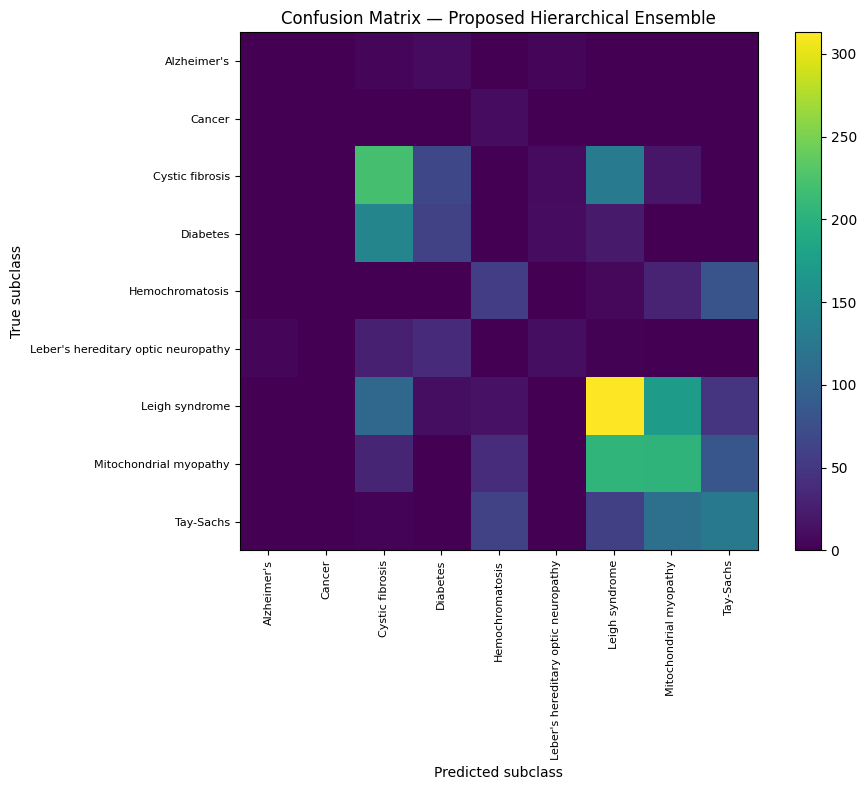

In [15]:

#@title 15. Per-class performance and confusion matrix
pred2 = p2_test.argmax(1)

report = classification_report(
    y2_test, pred2,
    labels=np.arange(len(le2.classes_)),
    target_names=le2.classes_,
    output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report).T
display(report_df.round(4))
report_df.to_csv(OUT/"subclass_classification_report.csv")

cm = confusion_matrix(y2_test, pred2, labels=np.arange(len(le2.classes_)))
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(cm)
ax.set_title("Confusion Matrix — Proposed Hierarchical Ensemble")
ax.set_xlabel("Predicted subclass")
ax.set_ylabel("True subclass")
ax.set_xticks(range(len(le2.classes_)))
ax.set_yticks(range(len(le2.classes_)))
ax.set_xticklabels(le2.classes_, rotation=90, fontsize=8)
ax.set_yticklabels(le2.classes_, fontsize=8)
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(OUT/"confusion_matrix.png", dpi=220, bbox_inches="tight")
plt.show()


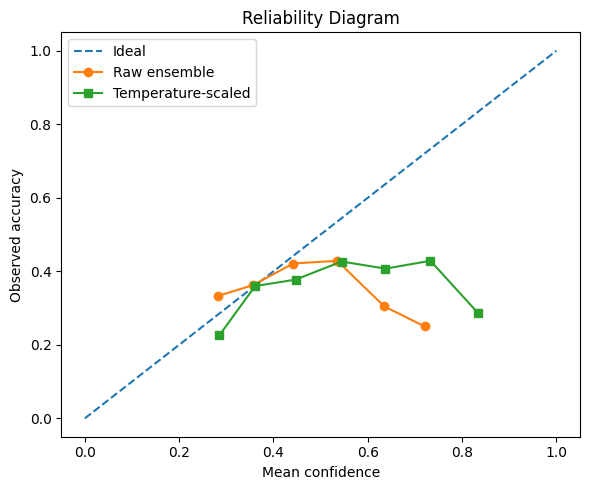

In [16]:

#@title 16. Reliability diagram
def reliability_points(y, prob, bins=10):
    conf = prob.max(1)
    pred = prob.argmax(1)
    corr = (pred == y).astype(float)
    edges = np.linspace(0,1,bins+1)
    xs, ys, ns = [], [], []
    for lo,hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            xs.append(conf[m].mean()); ys.append(corr[m].mean()); ns.append(m.sum())
    return np.array(xs), np.array(ys), np.array(ns)

fig, ax = plt.subplots(figsize=(6,5))
x0,y0,_ = reliability_points(y2_test, p2_test_raw)
x1,y1,_ = reliability_points(y2_test, p2_test)
ax.plot([0,1],[0,1],"--", label="Ideal")
ax.plot(x0,y0,marker="o",label="Raw ensemble")
ax.plot(x1,y1,marker="s",label="Temperature-scaled")
ax.set_xlabel("Mean confidence")
ax.set_ylabel("Observed accuracy")
ax.set_title("Reliability Diagram")
ax.legend()
fig.tight_layout()
fig.savefig(OUT/"reliability_diagram.png", dpi=220, bbox_inches="tight")
plt.show()


In [17]:

#@title 17. Robustness analysis: additional missingness
def inject_missingness(Xdf, rate, seed=42):
    rng = np.random.default_rng(seed)
    Xn = Xdf.copy()
    eligible = [c for c in Xn.columns if c not in ["record_missing_count","record_missing_fraction"]]
    mask = rng.random((len(Xn), len(eligible))) < rate
    for j,c in enumerate(eligible):
        Xn.loc[mask[:,j], c] = np.nan
    return Xn

robust_rows = []
for rate in [0.00, 0.05, 0.10, 0.20]:
    Xr = inject_missingness(X_test.copy(), rate, SEED + int(rate*1000))
    # Recompute engineered missingness features consistently.
    Xr_fe = add_biological_features(Xr.drop(columns=[
        c for c in ["record_missing_count","record_missing_fraction",
                    "inheritance_evidence_count","inheritance_evidence_fraction",
                    "symptom_burden","symptom_observed_count",
                    "parent_age_mean","parent_age_gap_abs"] if c in Xr.columns
    ], errors="ignore"))
    # Align engineered columns to training schema.
    Xr_fe = Xr_fe.reindex(columns=X_fit.columns)
    Zr = preprocessor.transform(Xr_fe)

    p1r_each = {n:m.predict_proba(Zr) for n,m in stage1_fitted.items()}
    p1r = average_probs(p1r_each, weights1)
    Z2r = sparse.hstack([Zr, sparse.csr_matrix(p1r)], format="csr")
    p2r_each = {n:m.predict_proba(Z2r) for n,m in stage2_fitted.items()}
    p2r = temperature_scale(average_probs(p2r_each, weights2), T_star)

    row = metric_row(f"Missingness_{int(rate*100)}pct", y2_test, p2r)
    row["InjectedMissingRate"] = rate
    robust_rows.append(row)

robustness = pd.DataFrame(robust_rows)
display(robustness.round(4))
robustness.to_csv(OUT/"missingness_robustness.csv", index=False)


,Model,Accuracy,BalancedAccuracy,MacroPrecision,MacroRecall,MacroF1,WeightedF1,LogLoss,Brier,ECE,MacroAUROC_OVR,InjectedMissingRate
0,Missingness_0pct,0.3854,0.2653,0.2814,0.2653,0.2685,0.3788,1.3546,0.7117,0.0813,0.8612,0.00
1,Missingness_5pct,0.3718,0.2589,0.2729,0.2589,0.2608,0.3645,1.4083,0.7263,0.0824,0.8478,0.05
2,Missingness_10pct,0.3613,0.2477,0.2727,0.2477,0.2525,0.3527,1.4596,0.7399,0.0858,0.8358,0.10
3,Missingness_20pct,0.3481,0.2368,0.2566,0.2368,0.2356,0.3341,1.5236,0.7571,0.0862,0.8137,0.20


In [18]:

#@title 18. Subgroup audit (sex/gender if present)
candidate_group_cols = [c for c in X_test.columns if c.lower() in ["gender","sex"] or "gender" in c.lower()]
fairness_rows = []

if candidate_group_cols:
    gcol = candidate_group_cols[0]
    groups = X_test[gcol].astype(str).fillna("Missing")
    for g in sorted(groups.unique()):
        m = (groups.values == g)
        if m.sum() < 20:
            continue
        fairness_rows.append({
            "GroupColumn": gcol,
            "Group": g,
            "N": int(m.sum()),
            "Accuracy": accuracy_score(y2_test[m], pred2[m]),
            "MacroF1": f1_score(y2_test[m], pred2[m], average="macro", zero_division=0),
            "MeanConfidence": p2_test[m].max(1).mean()
        })
    fairness_df = pd.DataFrame(fairness_rows)
    display(fairness_df.round(4))
    fairness_df.to_csv(OUT/"subgroup_audit.csv", index=False)
else:
    print("No sex/gender field detected; subgroup audit skipped.")


,GroupColumn,Group,N,Accuracy,MacroF1,MeanConfidence
0,Gender,Ambiguous,790,0.3772,0.2561,0.4678
1,Gender,Female,759,0.4111,0.2839,0.4685
2,Gender,Male,796,0.3706,0.2662,0.4699
3,Gender,nan,229,0.3799,0.2487,0.4457


,Feature,ImportanceMean,ImportanceStd
39,Symptom 5,0.05123,0.00755
44,symptom_burden,0.05103,0.00506
38,Symptom 4,0.03785,0.00779
36,Symptom 2,0.01762,0.00836
1,Genes in mother's side,0.00810,0.00488
4,Paternal gene,0.00715,0.00707
37,Symptom 3,0.00648,0.01169
3,Maternal gene,0.00228,0.00702
40,record_missing_count,0.00100,0.00231
2,Inherited from father,0.00071,0.00343


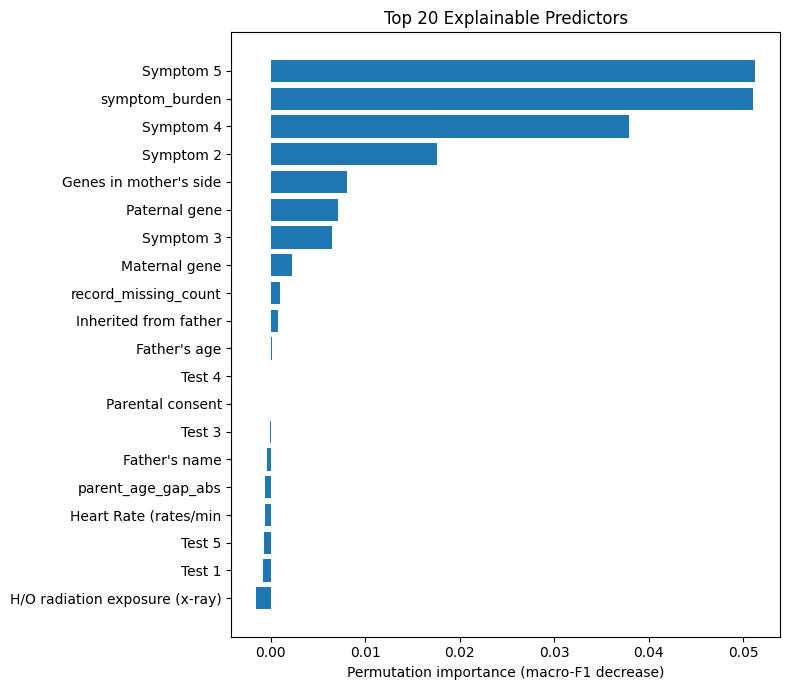

,EncodedFeature,MeanAbsSHAP
1804,stage1_prob_Multifactorial genetic inheritance...,1.034604
20,num__symptom_burden,0.575220
1803,stage1_prob_Mitochondrial genetic inheritance ...,0.278868
15,num__Symptom 5,0.186745
1805,stage1_prob_Single-gene inheritance diseases,0.185996
14,num__Symptom 4,0.161324
19,num__inheritance_evidence_fraction,0.153177
21,num__symptom_observed_count,0.121830
1,num__Blood cell count (mcL),0.095507
10,num__White Blood cell count (thousand per micr...,0.081584


In [19]:

#@title 19. Explainability: permutation importance + optional SHAP
# Model-agnostic permutation importance on the strongest *flat* baseline keeps
# feature names interpretable and computation low.
# Scoring uses macro-F1 and a capped sample in QUICK_RUN mode.

sample_n = min(len(X_test), 800 if QUICK_RUN else 2500)
sample_idx = np.random.default_rng(SEED).choice(len(X_test), sample_n, replace=False)

# A full sklearn Pipeline is used here so importance is measured at original feature level.
flat_pipe = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", ExtraTreesClassifier(
        n_estimators=140 if QUICK_RUN else 350,
        max_features="sqrt", min_samples_leaf=2,
        class_weight="balanced", random_state=SEED, n_jobs=-1
    ))
])
flat_pipe.fit(X_fit, y2_fit)

perm = permutation_importance(
    flat_pipe, X_test.iloc[sample_idx], y2_test[sample_idx],
    scoring="f1_macro", n_repeats=3 if QUICK_RUN else 8,
    random_state=SEED, n_jobs=-1
)
imp_df = pd.DataFrame({
    "Feature": X_test.columns,
    "ImportanceMean": perm.importances_mean,
    "ImportanceStd": perm.importances_std
}).sort_values("ImportanceMean", ascending=False)

display(imp_df.head(20).round(5))
imp_df.to_csv(OUT/"permutation_feature_importance.csv", index=False)

top = imp_df.head(20).sort_values("ImportanceMean")
fig, ax = plt.subplots(figsize=(8,7))
ax.barh(top["Feature"], top["ImportanceMean"])
ax.set_xlabel("Permutation importance (macro-F1 decrease)")
ax.set_title("Top 20 Explainable Predictors")
fig.tight_layout()
fig.savefig(OUT/"feature_importance_top20.png", dpi=220, bbox_inches="tight")
plt.show()

# SHAP on LightGBM encoded features (optional but enabled).
try:
    import shap
    feature_names = list(preprocessor.get_feature_names_out()) + [
        f"stage1_prob_{c}" for c in le1.classes_
    ]
    Xsh = Z2_test[:min(300 if QUICK_RUN else 1000, Z2_test.shape[0])]
    if sparse.issparse(Xsh):
        Xsh_dense = Xsh.toarray()
    else:
        Xsh_dense = np.asarray(Xsh)

    explainer = shap.TreeExplainer(stage2_fitted["LightGBM"])
    sv = explainer.shap_values(Xsh_dense)

    # Save a compact global importance table robustly across SHAP output formats.
    arr = np.asarray(sv)
    if arr.ndim == 3:
        # possible [samples, features, classes] or [classes, samples, features]
        if arr.shape[0] == Xsh_dense.shape[0]:
            glob = np.abs(arr).mean(axis=(0,2))
        else:
            glob = np.abs(arr).mean(axis=(0,1))
    elif isinstance(sv, list):
        glob = np.mean([np.abs(a).mean(axis=0) for a in sv], axis=0)
    else:
        glob = np.abs(arr).mean(axis=0)

    shap_df = pd.DataFrame({
        "EncodedFeature": feature_names[:len(glob)],
        "MeanAbsSHAP": glob[:len(feature_names)]
    }).sort_values("MeanAbsSHAP", ascending=False)
    display(shap_df.head(25))
    shap_df.to_csv(OUT/"shap_global_importance.csv", index=False)
except Exception as e:
    print("SHAP optional step skipped safely:", repr(e))


In [20]:

#@title 20. Save patient-level predictions and conformal sets
sets90 = conformal_outputs[0.10]
pred_df = pd.DataFrame({
    "True_Genetic_Disorder": le1.inverse_transform(y1_test),
    "Pred_Genetic_Disorder": le1.inverse_transform(p1_test.argmax(1)),
    "True_Disorder_Subclass": le2.inverse_transform(y2_test),
    "Pred_Disorder_Subclass": le2.inverse_transform(pred2),
    "PredictionConfidence": p2_test.max(1),
    "ConformalSetSize_90": sets90.sum(1),
})

set_labels = []
for i in range(len(sets90)):
    labels = le2.classes_[sets90[i]]
    set_labels.append(" | ".join(map(str, labels)))
pred_df["ConformalSet_90"] = set_labels

display(pred_df.head())
pred_df.to_csv(OUT/"test_predictions_with_uncertainty.csv", index=False)


,True_Genetic_Disorder,Pred_Genetic_Disorder,True_Disorder_Subclass,Pred_Disorder_Subclass,PredictionConfidence,ConformalSetSize_90,ConformalSet_90
0,Mitochondrial genetic inheritance disorders,Mitochondrial genetic inheritance disorders,Mitochondrial myopathy,Mitochondrial myopathy,0.391950,3,Leigh syndrome | Mitochondrial myopathy | Tay-...
1,Mitochondrial genetic inheritance disorders,Mitochondrial genetic inheritance disorders,Leigh syndrome,Leigh syndrome,0.533185,3,Cystic fibrosis | Leigh syndrome | Mitochondri...
2,Single-gene inheritance diseases,Mitochondrial genetic inheritance disorders,Cystic fibrosis,Leigh syndrome,0.403793,3,Leigh syndrome | Mitochondrial myopathy | Tay-...
3,Single-gene inheritance diseases,Single-gene inheritance diseases,Cystic fibrosis,Cystic fibrosis,0.555288,3,Cystic fibrosis | Diabetes | Leigh syndrome
4,Mitochondrial genetic inheritance disorders,Mitochondrial genetic inheritance disorders,Leigh syndrome,Leigh syndrome,0.364582,3,Cystic fibrosis | Diabetes | Leigh syndrome


In [21]:

#@title 21. Publication-ready master results table
master = pd.concat([
    pd.DataFrame([metric_row("Flat_BioFeature_ExtraTrees", y2_test, p_flat)]),
    pd.DataFrame([metric_row("Proposed_Hierarchical_Ensemble_Raw", y2_test, p2_test_raw)]),
    pd.DataFrame([metric_row("Proposed_Hierarchical_Ensemble_Calibrated", y2_test, p2_test)]),
], ignore_index=True)

display(master.round(4))
master.to_csv(OUT/"master_test_results.csv", index=False)

best = master.sort_values("MacroF1", ascending=False).iloc[0]
print(f"Best by Macro-F1: {best['Model']}")
print(f"Macro-F1={best['MacroF1']:.4f}, Accuracy={best['Accuracy']:.4f}, ECE={best['ECE']:.4f}")


,Model,Accuracy,BalancedAccuracy,MacroPrecision,MacroRecall,MacroF1,WeightedF1,LogLoss,Brier,ECE,MacroAUROC_OVR
0,Flat_BioFeature_ExtraTrees,0.3594,0.2718,0.2887,0.2718,0.2750,0.3558,1.7182,0.7835,0.1572,0.8422
1,Proposed_Hierarchical_Ensemble_Raw,0.3854,0.2653,0.2814,0.2653,0.2685,0.3788,1.3721,0.7026,0.0250,0.8617
2,Proposed_Hierarchical_Ensemble_Calibrated,0.3854,0.2653,0.2814,0.2653,0.2685,0.3788,1.3546,0.7117,0.0813,0.8612


Best by Macro-F1: Flat_BioFeature_ExtraTrees
Macro-F1=0.2750, Accuracy=0.3594, ECE=0.1572


In [22]:

#@title 22. Experiment configuration and reproducibility record
config = {
    "seed": SEED,
    "quick_run": QUICK_RUN,
    "cv_folds": N_SPLITS,
    "bootstrap_replicates": BOOTSTRAPS,
    "dataset_handle": DATASET_HANDLE,
    "train_csv": str(TRAIN_CSV),
    "n_total_after_target_drop": int(len(df)),
    "n_fit": int(len(X_fit)),
    "n_calibration": int(len(X_cal)),
    "n_test": int(len(X_test)),
    "stage1_classes": list(map(str, le1.classes_)),
    "stage2_classes": list(map(str, le2.classes_)),
    "stage1_weights": {k:float(v) for k,v in zip(stage1_models,weights1)},
    "stage2_weights": {k:float(v) for k,v in zip(stage2_models,weights2)},
    "temperature": T_star,
    "removed_identifier_columns": drop_cols,
}
with open(OUT/"experiment_config.json","w") as f:
    json.dump(config,f,indent=2)
print(json.dumps(config, indent=2))


{
  "seed": 42,
  "quick_run": false,
  "cv_folds": 5,
  "bootstrap_replicates": 1500,
  "dataset_handle": "aibuzz/predict-the-genetic-disorders-datasetof-genomes",
  "train_csv": "/root/.cache/kagglehub/datasets/aibuzz/predict-the-genetic-disorders-datasetof-genomes/versions/1/train_genetic_disorders.csv",
  "n_total_after_target_drop": 17160,
  "n_fit": 12012,
  "n_calibration": 2574,
  "n_test": 2574,
  "stage1_classes": [
    "Mitochondrial genetic inheritance disorders",
    "Multifactorial genetic inheritance disorders",
    "Single-gene inheritance diseases"
  ],
  "stage2_classes": [
    "Alzheimer's",
    "Cancer",
    "Cystic fibrosis",
    "Diabetes",
    "Hemochromatosis",
    "Leber's hereditary optic neuropathy",
    "Leigh syndrome",
    "Mitochondrial myopathy",
    "Tay-Sachs"
  ],
  "stage1_weights": {
    "ExtraTrees": 0.3256036537360895,
    "XGBoost": 0.3325382662921863,
    "LightGBM": 0.34185807997172407
  },
  "stage2_weights": {
    "ExtraTrees": 0.302308357876

In [23]:

#@title FULL-RUN verification checklist
assert QUICK_RUN is False, "This notebook is intended for FULL_RUN. Set QUICK_RUN=False."
assert N_SPLITS == 5, f"Expected 5 OOF folds in FULL_RUN, got {N_SPLITS}"
assert BOOTSTRAPS == 1500, f"Expected 1500 bootstrap replicates in FULL_RUN, got {BOOTSTRAPS}"

required_outputs = [
    "stage1_test_metrics.csv",
    "calibration_comparison.csv",
    "conformal_prediction_sets.csv",
    "ablation_study.csv",
    "bootstrap_confidence_intervals.csv",
    "paired_bootstrap_significance.csv",
    "missingness_robustness.csv",
    "subclass_classification_report.csv",
    "confusion_matrix.png",
    "reliability_diagram.png",
    "permutation_feature_importance.csv",
    "feature_importance_top20.png",
    "test_predictions_with_uncertainty.csv",
    "master_test_results.csv",
    "experiment_config.json",
]
missing = [f for f in required_outputs if not (OUT/f).exists()]
if missing:
    print("WARNING: The following expected outputs are not present yet:")
    for f in missing:
        print(" -", f)
    print("This usually means an earlier cell did not complete. Re-run from that cell.")
else:
    print("FULL RUN COMPLETE: all required publication outputs are present.")


FULL RUN COMPLETE: all required publication outputs are present.


In [24]:

#@title 23. Download all results as one ZIP
zip_path = Path("/content/Q1_Genetic_Disorder_All_Results.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in OUT.rglob("*"):
        if p.is_file():
            zf.write(p, arcname=p.relative_to(OUT))

print("Created:", zip_path)
print("Files:")
for p in sorted(OUT.iterdir()):
    print(" -", p.name)

from google.colab import files
files.download(str(zip_path))


Created: /content/Q1_Genetic_Disorder_All_Results.zip
Files:
 - ablation_study.csv
 - bootstrap_confidence_intervals.csv
 - calibration_comparison.csv
 - conformal_prediction_sets.csv
 - confusion_matrix.png
 - experiment_config.json
 - feature_importance_top20.png
 - master_test_results.csv
 - missingness_robustness.csv
 - paired_bootstrap_significance.csv
 - permutation_feature_importance.csv
 - reliability_diagram.png
 - shap_global_importance.csv
 - stage1_test_metrics.csv
 - subclass_classification_report.csv
 - subgroup_audit.csv
 - test_predictions_with_uncertainty.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## What to report in the paper

Use the generated files rather than manually copying values:

1. `master_test_results.csv` — main comparison.
2. `ablation_study.csv` — contribution of biological features, hierarchy, ensemble and calibration.
3. `conformal_prediction_sets.csv` — 95%, 90% and 80% uncertainty coverage/set size.
4. `bootstrap_confidence_intervals.csv` — 95% confidence intervals.
5. `paired_bootstrap_significance.csv` — statistical comparison against the strong flat baseline.
6. `missingness_robustness.csv` — robustness at 0%, 5%, 10%, 20% additional missingness.
7. `subgroup_audit.csv` — subgroup audit when a gender/sex column is available.
8. `permutation_feature_importance.csv` and `shap_global_importance.csv` — explainability.
9. `test_predictions_with_uncertainty.csv` — auditable patient-level predictions and 90% conformal sets.

### Recommended publication protocol
This notebook is already configured for the **FULL publication run** (`QUICK_RUN=False`). Open it in Google Colab and use **Runtime → Run all**. Use only the outputs generated by this full run in the manuscript.

### Claims to avoid
Do not describe this model as a clinical diagnostic system. The dataset is a public challenge dataset and the notebook performs retrospective machine-learning evaluation. External clinical validation is required before any clinical-deployment claim.
